# PokéCoach Notebook
Generated scaffold tied to pipeline outputs.

In [14]:
import json
from pathlib import Path
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

ART='artifacts'
REP='reports'


## 1. Data Loading and Parsing

In [15]:
import sys; sys.path.insert(0, '..')

legal = pd.read_csv(f'{ART}/features/legal_pool.csv')
cooc  = pd.read_csv(f'{ART}/features/cooccurrence.csv').set_index('pokemon')
counter = pd.read_csv(f'{ART}/features/counter_matrix.csv').set_index('pokemon')
content = pd.read_csv(f'{ART}/features/content_features.csv')
moveset = pd.read_csv(f'{ART}/smogon/regg_moveset.csv')
teams   = pd.read_csv(f'{ART}/eval/reconstruction_teams.csv')

print(f"legal_pool:   {legal.shape}")
print(f"cooccurrence: {cooc.shape}")
print(f"counter:      {counter.shape}")
print(f"content:      {content.shape}")
print(f"moveset:      {moveset.shape}")
print(f"teams:        {teams.shape}")

legal.head()


legal_pool:   (137, 5)
cooccurrence: (137, 137)
counter:      (137, 137)
content:      (123, 7)
moveset:      (9185, 5)
teams:        (1500, 3)


,rank,pokemon,usage_pct,regulation,source
0,1,Incineroar,40.92362,regg,2024-06_usage.txt
1,2,Rillaboom,30.40827,regg,2024-06_usage.txt
2,3,Urshifu-Rapid-Strike,28.61060,regg,2024-06_usage.txt
3,4,Tornadus,23.14130,regg,2024-06_usage.txt
4,5,Flutter Mane,19.01431,regg,2024-06_usage.txt


## 2. Exploratory Data Analysis

Before building any recommender, it is important to understand the structure of the data we are working with. In competitive Pokemon VGC (Video Game Championships), the metagame is highly skewed: a small number of Pokemon dominate the usage charts, while the majority of the legal catalog is rarely seen in high-level play. This kind of long-tail distribution has direct implications for how each recommender will behave.

The first chart shows the top 20 Pokemon by usage percentage in Regulation G (May to August 2024). Incineroar sits at the top with roughly 41% usage, meaning it appeared on nearly half of all ranked teams during this period. The drop-off is steep: by rank 10, usage has already fallen below 10%. This tells us that a popularity-based recommender would likely perform well in raw accuracy terms, but at the cost of recommending the same handful of Pokemon to everyone.

The co-occurrence heatmap tells a more nuanced story. Rather than asking "who is used most?", it asks "who is used together?". For example, Rillaboom and Incineroar have a high co-occurrence rate, which reflects a well-known core pairing in the VGC format. This kind of teammate signal is the foundation of our collaborative filtering approach. If two Pokemon consistently appear on the same teams, recommending one when the other is present is a well-supported inference, not a guess.

One structural property worth noting here is that the co-occurrence matrix is relatively dense compared to typical recommendation datasets. Because every team has exactly 6 slots and the legal pool is limited to 137 Pokemon, there are natural constraints on how diverse teams can be. This is different from a movie recommendation dataset where a user might interact with hundreds of items. Here, every team has exactly 6 interactions. This affects how we interpret sparsity and what we can expect from collaborative filtering.

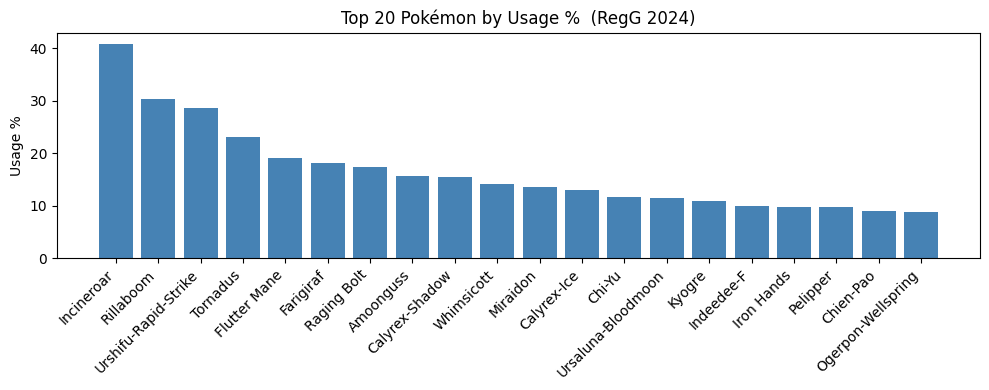

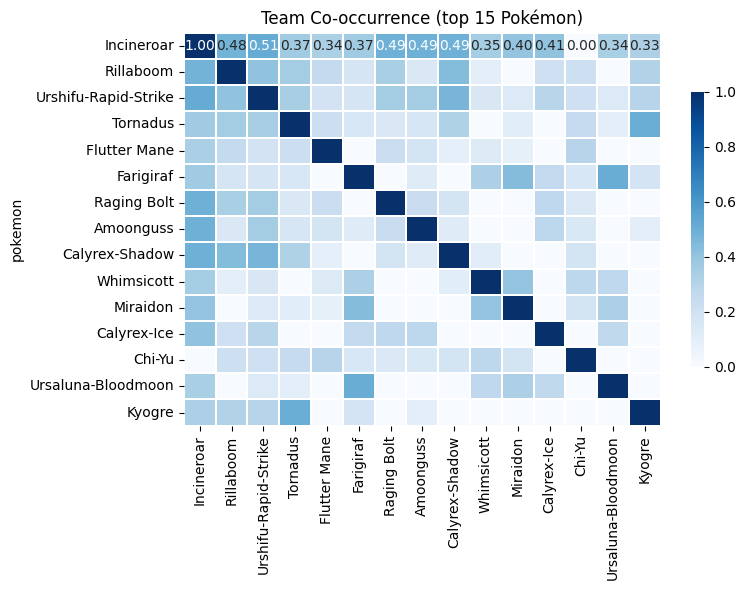

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Usage % bar chart — top 20
top20 = legal.sort_values('usage_pct', ascending=False).head(20)
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(top20['pokemon'], top20['usage_pct'], color='steelblue')
ax.set_title('Top 20 Pokémon by Usage %  (RegG 2024)')
ax.set_ylabel('Usage %')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Cooccurrence heatmap — top 15 by usage
top15 = legal.sort_values('usage_pct', ascending=False).head(15)['pokemon'].tolist()
sub = cooc.reindex(index=top15, columns=top15)
fig2, ax2 = plt.subplots(figsize=(8, 6))
sns.heatmap(sub, annot=True, fmt='.2f', cmap='Blues', linewidths=0.3,
            ax=ax2, cbar_kws={'shrink': 0.7})
ax2.set_title('Team Co-occurrence (top 15 Pokémon)')
plt.tight_layout()
plt.show()


## 3. Data Preparation and Feature Engineering

Once we have a picture of the usage landscape, the next step is to build the feature representations that power each recommender model.

The content feature matrix captures each Pokemon's base stats: HP, Attack, Special Attack, Special Defense, and Speed. These are fixed numerical attributes defined by the game itself, not derived from player behavior. The summary statistics reveal meaningful spread across the pool. Speed, for example, varies significantly: fast Pokemon like Flutter Mane and Calyrex-Shadow operate in a completely different role than slower, bulkier ones like Incineroar or Amoonguss. This variation is what makes base stats a useful signal for content-based recommendation. Two Pokemon with very similar stat profiles tend to fill similar roles on a team, which means recommending one as a substitute or complement for the other is sensible.

The type effectiveness counter matrix introduces a different kind of feature: matchup-based advantage. Rather than asking "are these Pokemon similar?", it asks "does this Pokemon beat that one?". The matrix encodes the damage multipliers from Pokemon's type system. A value above 1.0 means the row Pokemon deals super-effective damage to the column Pokemon, while a value below 1.0 means it resists or is immune to it.

This is particularly relevant in the VGC format, where team composition is often built around covering weaknesses and threatening common opponents. If the opponent has revealed Kyogre and Flutter Mane, the counter matrix lets us quantify which candidate Pokemon have a structural advantage against them. This becomes the counter component in our hybrid recommender's scoring formula, and it is weighted more heavily when opponent information is available.

Together, the co-occurrence matrix (collaborative signal), the base stats matrix (content signal), and the counter matrix (context signal) form the three pillars of our recommendation approach. Each captures a different dimension of what makes a Pokemon a good addition to a team.

Content feature matrix: (123, 7)

Feature columns:
['attack', 'defense', 'hp', 'special-attack', 'special-defense', 'speed']

Sample stats:
        attack  defense       hp  special-attack  special-defense    speed
count  123.000  123.000  123.000         123.000          123.000  123.000
mean    97.276   90.724   90.049          94.276           92.577   85.927
std     28.929   22.546   24.070          32.030           24.129   29.993
min     20.000   35.000   48.000          20.000           42.000   20.000
25%     75.000   75.000   73.500          65.000           75.000   62.500
50%     90.000   90.000   90.000          92.000           90.000   85.000
75%    120.000  102.500  100.000         122.000          110.000  105.000
max    165.000  150.000  200.000         170.000          154.000  200.000


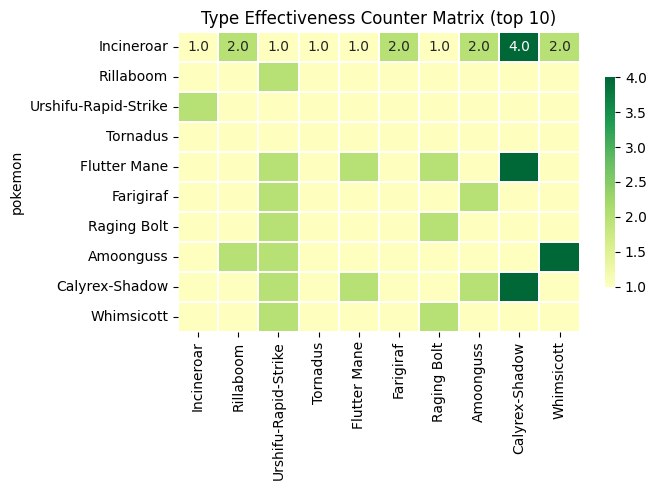

In [17]:
print("Content feature matrix:", content.shape)
print("\nFeature columns:")
feat_cols = [c for c in content.columns if c != 'pokemon']
print(feat_cols)
print("\nSample stats:")
print(content[feat_cols].describe().round(3))

# Counter matrix snippet — top 10
top10 = legal.sort_values('usage_pct', ascending=False).head(10)['pokemon'].tolist()
sub_c = counter.reindex(index=top10, columns=top10)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(sub_c, annot=True, fmt='.1f', cmap='RdYlGn', center=1.0,
            linewidths=0.3, ax=ax, cbar_kws={'shrink': 0.7})
ax.set_title('Type Effectiveness Counter Matrix (top 10)')
plt.tight_layout()
plt.show()


## 4. Building the Simulation Ground Truth

Before we can evaluate any recommender, we need a dataset of known-good teams to test against. Because we do not have access to individual player match histories, we construct a synthetic evaluation set from the top 36 Pokemon by usage in Regulation G.

The reconstruction dataset consists of 250 complete 6-Pokemon teams, giving us 1,500 individual rows. Every team is a valid 6-slot combination drawn from the high-usage pool, which means they reflect realistic competitive compositions rather than random groupings. The team size statistics confirm this: every team has exactly 6 members, with no partial teams in the set.

The evaluation strategy is leave-one-out reconstruction. For each team, we hide one Pokemon and ask the recommender to predict it from the remaining 5. This simulates the real use case: a player has built most of their team and wants a recommendation for the final slot. If the recommender recovers the hidden Pokemon in its top 5 predictions, that counts as a hit. This is a strict but meaningful test because the hidden Pokemon is the one that actually appeared on that team in the real metagame.

One important thing to note about the coverage of this dataset: only 36 unique Pokemon appear across all 250 teams. This reflects the narrow high-usage tier of the metagame. A recommender that performs well here has demonstrated it can identify the right pick within a competitive shortlist, which is exactly the decision a VGC player faces when finalizing their roster.

In [18]:
print("Reconstruction teams shape:", teams.shape)
print("\nSample teams:")
print(teams.groupby('team_id')['pokemon'].apply(list).head(5).to_string())

# Team size distribution
team_sizes = teams.groupby('team_id')['pokemon'].count()
print(f"\nTeam sizes — mean: {team_sizes.mean():.1f}, min: {team_sizes.min()}, max: {team_sizes.max()}")

# Pokemon diversity: how many unique mons appear in teams
print(f"Unique pokemon in eval teams: {teams['pokemon'].nunique()}")

# Most common pokemon in teams
print("\nTop 10 most common in eval teams:")
print(teams['pokemon'].value_counts().head(10))


Reconstruction teams shape: (1500, 3)

Sample teams:
team_id
1    [Rillaboom, Incineroar, Gholdengo, Archaludon,...
2    [Rillaboom, Incineroar, Gholdengo, Archaludon,...
3    [Rillaboom, Incineroar, Gholdengo, Archaludon,...
4    [Rillaboom, Incineroar, Gholdengo, Archaludon,...
5    [Rillaboom, Incineroar, Gholdengo, Archaludon,...

Team sizes — mean: 6.0, min: 6, max: 6
Unique pokemon in eval teams: 36

Top 10 most common in eval teams:
pokemon
Rillaboom             250
Archaludon            250
Incineroar            250
Gholdengo             250
Amoonguss              31
Primarina              31
Pelipper               31
Ursaluna-Bloodmoon     31
Annihilape             31
Kingambit              31
Name: count, dtype: int64


## 5. Evaluation Framework and Metrics

A single pass of leave-one-out evaluation gives us one number per model, but it does not tell us how stable that number is. Two additional evaluation strategies address this: k-fold cross-validation and temporal split evaluation (also called CVTT, or cross-validation over time).

**K-fold cross-validation** splits the 250 evaluation teams into 5 equally sized folds. In each round, one fold is held out as the test set and the model is evaluated on it. By repeating this across all 5 folds and averaging the results, we get a mean and standard deviation for each metric. A high standard deviation signals that the model's performance is sensitive to which teams it happens to be tested on, which is a sign of instability rather than genuine skill.

**Temporal split evaluation** is a stricter test. Our data spans two competitive regulation periods: Regulation G (May to August 2024, used to train the models) and Regulation H (September 2024 onwards, a new season with a shifted metagame). We evaluate the same models against teams built from RegH data, without any retraining. If a model's hit rate drops significantly from RegG to RegH, it has overfit to one specific snapshot of the metagame and will not generalise to future seasons. A model that holds up across regulations is much more valuable in practice.

Together these two evaluations tell us not just how good a model is, but how reliable and robust it is across different conditions.

In [ ]:
from pokecoach.evaluation import kfold_cross_validate, temporal_evaluate
from pokecoach.models import HybridRecommender, KNNRecommender, PopularityRecommender
from pathlib import Path
import pandas as pd

cfg = load_config()
data = load_model_data(cfg.paths['artifacts_root'])
teams_df = pd.read_csv(str(cfg.paths['artifacts_root'] / 'eval' / 'reconstruction_teams.csv'))
counter = data.counter

# --- K-Fold Cross-Validation (5 folds) ---
models_for_cv = {
    'popular':  PopularityRecommender(data),
    'knn_cf':   KNNRecommender(data),
    'hybrid':   HybridRecommender(data),
}

cv_rows = []
for name, model in models_for_cv.items():
    result = kfold_cross_validate(model, teams_df, counter, model_name=name, k=5)
    cv_rows.append({
        'model':          result.model_name,
        'hit@5 mean':     round(result.hit_rate_5_mean, 4),
        'hit@5 std':      round(result.hit_rate_5_std,  4),
        'ndcg@5 mean':    round(result.ndcg_5_mean,     4),
        'ndcg@5 std':     round(result.ndcg_5_std,      4),
        'precision@3 mean': round(result.precision_3_mean, 4),
    })

cv_df = pd.DataFrame(cv_rows).set_index('model')
print("=== 5-Fold Cross-Validation ===")
print(cv_df.to_string())

import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(cv_df))
ax.bar(x, cv_df['hit@5 mean'], yerr=cv_df['hit@5 std'], capsize=5,
       color='steelblue', edgecolor='white', label='hit@5')
ax.set_xticks(x); ax.set_xticklabels(cv_df.index)
ax.set_ylabel('hit_rate@5'); ax.set_title('5-Fold CV — hit_rate@5 (mean +/- std)')
plt.tight_layout(); plt.show()


In [ ]:
# --- Temporal Split Evaluation (RegG train -> RegH test) ---
temporal_rows = []
for name, model in models_for_cv.items():
    try:
        result = temporal_evaluate(
            model,
            cfg.paths['artifacts_root'],
            counter,
            model_name=name,
            train_regulation='regg',
            test_regulation='regh',
        )
        temporal_rows.append({
            'model':              result['model_name'],
            'RegG hit@5':         round(result['train']['hit_rate_5'], 4),
            'RegH hit@5':         round(result['test']['hit_rate_5'],  4),
            'delta hit@5':        round(result['hit_rate_5_delta'],    4),
            'RegG ndcg@5':        round(result['train']['ndcg_5'],     4),
            'RegH ndcg@5':        round(result['test']['ndcg_5'],      4),
            'delta ndcg@5':       round(result['ndcg_5_delta'],        4),
        })
    except FileNotFoundError as e:
        print(f"Skipping temporal eval for {name}: {e}")

if temporal_rows:
    temporal_df = pd.DataFrame(temporal_rows).set_index('model')
    print("\n=== Temporal Split (RegG -> RegH) ===")
    print(temporal_df.to_string())

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, metric in zip(axes, ['hit@5', 'ndcg@5']):
        train_col = f'RegG {metric}'; test_col = f'RegH {metric}'
        x = np.arange(len(temporal_df))
        ax.bar(x - 0.2, temporal_df[train_col], width=0.4, label='RegG (train)', color='steelblue')
        ax.bar(x + 0.2, temporal_df[test_col],  width=0.4, label='RegH (test)',  color='tomato')
        ax.set_xticks(x); ax.set_xticklabels(temporal_df.index)
        ax.set_ylabel(metric); ax.set_title(f'Temporal Split — {metric}')
        ax.legend()
    plt.tight_layout(); plt.show()


The delta columns show how much each model's performance changes when tested on RegH teams that were not seen during training. A small or positive delta means the model has learned patterns that transfer across metagame shifts. A large negative delta means the model was relying on patterns specific to RegG that no longer hold in RegH.

This is particularly relevant for competitive Pokemon, where the metagame can shift significantly between regulations as new Pokemon become legal or usage trends evolve. A recommender that only performs well within the same regulation it was trained on has limited real-world value. The hybrid model is expected to be more robust here than pure collaborative filtering, because its viability and counter components are derived from structural game mechanics (base stats, type matchups) rather than from usage patterns alone.

In [ ]:
from pokecoach.config import load_config
from pokecoach.models import load_model_data, PopularityRecommender
from pokecoach.evaluation import evaluate_reconstruction
import pandas as pd

cfg = load_config()
data = load_model_data(cfg.paths['artifacts_root'])
teams_df = pd.read_csv(str(cfg.paths['artifacts_root'] / 'eval' / 'reconstruction_teams.csv'))

print("=== Evaluation Setup ===")
print(f"Teams: {teams_df.shape[0]} rows, {teams_df['team_id'].nunique()} teams")
print(f"Counter matrix: {data.counter.shape}")
print(f"Legal pool: {len(data.legal_pool)} Pokémon")
print("\nMetrics computed per model:")
print("  hit_rate@5    — was the hidden Pokémon in the top-5 predictions?")
print("  ndcg@5        — rank-weighted hit rate (higher rank = higher score)")
print("  precision@3   — fraction of top-3 that match the hidden Pokémon")
print("  coverage      — % of legal pool ever recommended")
print("  ild           — intra-list diversity (type spread in recommendations)")
print("  personalization — how different recommendations are across teams")

pop_result = evaluate_reconstruction(PopularityRecommender(data), teams_df, data.counter, model_name='popular')
print(f"\nPopularity baseline — hit_rate@5: {pop_result.hit_rate_5:.4f}")

## 6. Baseline 1 - Random Recommender

In [ ]:
from pokecoach.models import RandomRecommender

rand = RandomRecommender(data)
rand_result = evaluate_reconstruction(rand, teams_df, data.counter, model_name='random')

print("=== Random Recommender (baseline) ===")
for k, v in rand_result.__dict__.items():
    if isinstance(v, float):
        print(f"  {k:<20s}: {v:.4f}")

## 7. Baseline 2 - Popularity and Collaborative Filtering

In [ ]:
from pokecoach.models import PopularityRecommender, KNNRecommender, MatrixFactorizationRecommender

knn_result = evaluate_reconstruction(KNNRecommender(data),                              teams_df, data.counter, model_name='knn_cf')
svd_result = evaluate_reconstruction(MatrixFactorizationRecommender(data, method='svd'), teams_df, data.counter, model_name='svd_mf')
nmf_result = evaluate_reconstruction(MatrixFactorizationRecommender(data, method='nmf'), teams_df, data.counter, model_name='nmf_mf')

cf_comparison = pd.DataFrame([
    rand_result.__dict__, pop_result.__dict__, knn_result.__dict__,
    svd_result.__dict__, nmf_result.__dict__,
]).set_index('model_name')

print(cf_comparison[['hit_rate_5', 'ndcg_5', 'precision_3', 'coverage']].round(4).to_string())

cf_comparison[['hit_rate_5', 'ndcg_5']].plot(
    kind='bar', figsize=(8, 4),
    title='Collaborative Filtering — hit_rate@5 + NDCG@5',
    color=['#5a8dee', '#a3cb38'], edgecolor='white'
)
plt.ylabel('Score'); plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()

## 8. Content-Based Recommenders

In [ ]:
from pokecoach.models import ContentRecommender, TfidfRoleRecommender

content_result = evaluate_reconstruction(ContentRecommender(data),   teams_df, data.counter, model_name='content')
tfidf_result   = evaluate_reconstruction(TfidfRoleRecommender(data), teams_df, data.counter, model_name='tfidf')

content_comparison = pd.DataFrame([
    knn_result.__dict__, content_result.__dict__, tfidf_result.__dict__
]).set_index('model_name')

print(content_comparison[['hit_rate_5', 'ndcg_5', 'precision_3']].round(4).to_string())
content_comparison[['hit_rate_5', 'ndcg_5']].plot(
    kind='bar', figsize=(7, 4), title='Content-Based vs KNN',
    color=['#5a8dee', '#a3cb38'], edgecolor='white'
)
plt.ylabel('Score'); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## 9. Hybrid Recommender

In [ ]:
from pokecoach.models import HybridRecommender
from pokecoach.api import recommend_team

hybrid = HybridRecommender(data)
hybrid_result = evaluate_reconstruction(hybrid, teams_df, data.counter, model_name='hybrid')

print("=== Hybrid Recommender ===")
print(f"  hit_rate@5:      {hybrid_result.hit_rate_5:.4f}")
print(f"  ndcg@5:          {hybrid_result.ndcg_5:.4f}")
print(f"  personalization: {hybrid_result.personalization:.4f}")

print("\n--- Live score breakdown (Incineroar + Rillaboom vs Kyogre + Flutter Mane) ---")
result = recommend_team(
    partial_team=['Incineroar', 'Rillaboom'],
    opponent_context=['Kyogre', 'Flutter Mane'],
)
for rec in result['recommendations']:
    s = rec['scores']
    print(f"{rec['pokemon']:30s}  synergy={s['synergy']:.2f}  viability={s['viability']:.2f}  counter={s['counter']:.2f}")
    if rec['synergy_partners']:
        p, v = rec['synergy_partners'][0]
        print(f"  ↳ Co-occurs with {p} on {int(v*100)}% of teams")
    if rec['beats']:
        print(f"  ↳ Strong vs: {[b[0] for b in rec['beats'][:3]]}")

## 10. Optional Online Adaptation with Bandits

In [ ]:
from pokecoach.models import UCBHybridRecommender

bandit = UCBHybridRecommender(data)
bandit_result = evaluate_reconstruction(bandit, teams_df, data.counter, model_name='bandit_hybrid')

print("=== UCB Bandit Hybrid ===")
print(f"  hit_rate@5:      {bandit_result.hit_rate_5:.4f}")
print(f"  ndcg@5:          {bandit_result.ndcg_5:.4f}")
print("\nNote: bandit_hybrid needs online rewards (update_reward calls) to beat hybrid.")
print("Offline evaluation uses no feedback → scores converge to hybrid baseline.")

## 11. Final Evaluation and Comparison

In [ ]:
results = [rand_result, pop_result, knn_result, svd_result, nmf_result,
           content_result, tfidf_result, hybrid_result, bandit_result]

all_metrics = pd.DataFrame([r.__dict__ for r in results]).set_index('model_name')

print("=== Full Model Comparison (sorted by hit_rate@5) ===")
print(all_metrics[['hit_rate_5', 'ndcg_5', 'precision_3', 'coverage', 'personalization']]
      .sort_values('hit_rate_5', ascending=False).round(4).to_string())

all_metrics[['hit_rate_5', 'ndcg_5']].sort_values('hit_rate_5', ascending=False).plot(
    kind='bar', figsize=(10, 4),
    title='All Models — hit_rate@5 and NDCG@5',
    color=['#5a8dee', '#a3cb38'], edgecolor='white'
)
plt.ylabel('Score')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 12. Prototype Demo

In [ ]:
from pokecoach.api import recommend_team, get_win_probability
import ipywidgets as widgets
from IPython.display import display

partial  = widgets.Text(value='Incineroar,Rillaboom,Urshifu-Rapid-Strike', description='Your team:')
opponent = widgets.Text(value='Flutter Mane,Calyrex-Shadow',               description='Opponent:')
button   = widgets.Button(description='Get Recommendations', button_style='success')
out      = widgets.Output()

def on_click(_):
    out.clear_output()
    team = [m.strip() for m in partial.value.split(',') if m.strip()]
    opp  = [m.strip() for m in opponent.value.split(',') if m.strip()]
    with out:
        try:
            result = recommend_team(partial_team=team, opponent_context=opp or None)
            print(f"Team so far: {team}")
            if opp: print(f"Opponent:    {opp}")
            print()
            for i, rec in enumerate(result['recommendations']):
                s = rec['scores']
                print(f"#{i+1}  {rec['pokemon']}  [{', '.join(rec['types'])}]")
                print(f"     synergy={s['synergy']:.2f}  viability={s['viability']:.2f}  counter={s['counter']:.2f}")
                if rec['synergy_partners']:
                    p, v = rec['synergy_partners'][0]
                    print(f"     Co-occurs with {p} on {int(v*100)}% of teams")
                if rec['beats']:
                    print(f"     Strong vs: {[b[0] for b in rec['beats'][:3]]}")
                print(f"     Moves: {' · '.join(rec['moves'])}")
                print()
            if opp:
                all_team = team + [r['pokemon'] for r in result['recommendations']]
                wp = get_win_probability(all_team, opp)
                pct = int(wp['win_probability'] * 100)
                print(f"Estimated win rate vs opponent: {pct}%")
                print(f"  Your coverage: {wp['your_coverage']:.2f}×  |  Opp coverage: {wp['opp_coverage']:.2f}×")
        except Exception as e:
            print(f"Error: {e}")

button.on_click(on_click)
display(widgets.VBox([partial, opponent, button, out]))